<a href="https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

**Question:** Which content pages should be prioritised for human review using only observable search-performance signals?

One row represents one pseudonymized content page. The output is a ranked priority score with an action label and a reason code. A content editor, SEO analyst, or strategist can use the queue to decide whether to inspect a page for a content refresh, a title/snippet review, a technical investigation, or no action.

A false positive can waste limited editorial capacity. A false negative can leave a potentially important page outside the review queue. Data and ML help because a large inventory cannot be inspected page by page using identical manual criteria. The system supports prioritisation; it does not replace editorial judgement.

In [16]:
import pandas as pd

research_scope = pd.DataFrame([
    {
        "unit_of_analysis": "One pseudonymized content page",
        "output": "Ranked priority score, action label, and reason code",
        "human_decision": "Inspect, refresh, review snippet, investigate, defer, or take no action",
        "wrong_positive_cost": "Editorial time is spent on a page that may not need intervention",
        "wrong_negative_cost": "A potentially important page may be missed"
    }
])

display(research_scope)

,unit_of_analysis,output,human_decision,wrong_positive_cost,wrong_negative_cost
0,One pseudonymized content page,"Ranked priority score, action label, and reaso...","Inspect, refresh, review snippet, investigate,...",Editorial time is spent on a page that may not...,A potentially important page may be missed


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data and public safety

The analysis uses the FlyRank ML Internship warehouse release and the `fact_content_daily_performance` table for March 2026. The raw warehouse grain is one pseudonymized client-content-date record.

The feature window is 1–15 March 2026. The later window is 16–31 March 2026 and is used only to construct the historical decline proxy. The page-level feature frame keeps pages with at least 100 prior-period impressions.

The analysis deliberately excludes client and content IDs from model features. They are used only for grouping and validation. Later-window impressions, the decline label, and ratios derived from later data are excluded because they would leak future outcome information. No client names, domains, URLs, private queries, or access tokens are included in this notebook.

In [17]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

In [18]:
import os
import getpass
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

print("Token loaded safely.")

Token loaded safely.


In [19]:
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

feature_frame = con.sql(f"""
    WITH page_windows AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_impressions ELSE 0 END
            ) AS prior_15d_impressions,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_clicks ELSE 0 END
            ) AS prior_15d_clicks,

            AVG(
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN gsc_avg_position END
            ) AS prior_15d_avg_position,

            COUNT(DISTINCT
                CASE WHEN report_date BETWEEN DATE '2026-03-01'
                                     AND DATE '2026-03-15'
                THEN report_date END
            ) AS prior_15d_active_days,

            SUM(
                CASE WHEN report_date BETWEEN DATE '2026-03-16'
                                     AND DATE '2026-03-31'
                THEN gsc_impressions ELSE 0 END
            ) AS next_16d_impressions

        FROM {MARCH}
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        *,
        CASE
            WHEN prior_15d_impressions > 0
            THEN prior_15d_clicks / prior_15d_impressions
            ELSE 0
        END AS prior_15d_ctr,

        CASE
            WHEN prior_15d_impressions >= 100
             AND next_16d_impressions <= 0.80 * prior_15d_impressions
            THEN 1
            ELSE 0
        END AS is_next_15d_declining

    FROM page_windows
    WHERE prior_15d_impressions >= 100
""").df()

print(f"Feature-frame rows: {len(feature_frame):,}")
print(
    "Later-window decline proxy rate: "
    f"{feature_frame['is_next_15d_declining'].mean():.1%}"
)

display(feature_frame.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature-frame rows: 77,540
Later-window decline proxy rate: 28.6%


,client_hash_id,content_hash_id,prior_15d_impressions,prior_15d_clicks,prior_15d_avg_position,prior_15d_active_days,next_16d_impressions,prior_15d_ctr,is_next_15d_declining
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4173.0,6.0,6.327311,15,2350.0,0.001438,1
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,245.0,0.0,3.906852,15,208.0,0.000000,0
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,3705.0,3.0,6.473735,15,1925.0,0.000810,1
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,2440.0,8.0,7.259861,15,2504.0,0.003279,0
4,client_73cda7b4e4f265ea,content_1855a661b4d36130,240.0,1.0,3.860842,15,189.0,0.004167,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The final model features are prior 15-day impressions, clicks, average position, CTR, and active days. The target is a later-window decline proxy: a page receives label 1 when it has at least 100 impressions in the first 15 days and has at least 20 percent fewer impressions in the later March window.

The transparent baseline uses only pre-decision impressions, average position, and CTR. It gives additional priority to visible pages with low CTR and positions in the 21–50 range.

Logistic Regression is the main readable model. Random Forest is included as a conservative non-linear comparison. Evaluation uses GroupShuffleSplit by pseudonymized client with `random_state=42`, so a client cannot appear in both training and test data.

The leakage audit forbids `next_16d_impressions`, `is_next_15d_declining`, future-derived ratios, IDs, and existing decision flags from model inputs.

In [20]:
methodology_audit = pd.DataFrame([
    {
        "item": "Feature window",
        "definition": "1–15 March 2026"
    },
    {
        "item": "Later outcome window",
        "definition": "16–31 March 2026"
    },
    {
        "item": "Final model features",
        "definition": (
            "prior_15d_impressions, prior_15d_clicks, "
            "prior_15d_avg_position, prior_15d_ctr, "
            "prior_15d_active_days"
        )
    },
    {
        "item": "Target proxy",
        "definition": (
            "Prior impressions >= 100 and later impressions <= "
            "80% of prior impressions"
        )
    },
    {
        "item": "Validation",
        "definition": "GroupShuffleSplit by pseudonymized client, random_state=42"
    },
    {
        "item": "Forbidden inputs",
        "definition": (
            "Future-window fields, label-derived fields, IDs, "
            "existing flags, and decision scores"
        )
    }
])

display(methodology_audit)

,item,definition
0,Feature window,1–15 March 2026
1,Later outcome window,16–31 March 2026
2,Final model features,"prior_15d_impressions, prior_15d_clicks, prior..."
3,Target proxy,Prior impressions >= 100 and later impressions...
4,Validation,"GroupShuffleSplit by pseudonymized client, ran..."
5,Forbidden inputs,"Future-window fields, label-derived fields, ID..."


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results on the same grouped client holdout

The grouped client holdout uses separate pseudonymized clients for training and testing. No client can appear in both groups.

The hand-written baseline, Logistic Regression, and Random Forest are measured using the same held-out pages and the same Precision@20 and Precision@50 metrics. The test base rate is reported beside all results because precision should be interpreted relative to the frequency of the decline proxy.

The result is expected to be mixed rather than uniformly positive. The baseline may be stronger for a short top-20 queue, while Logistic Regression may be stronger for a 50-page review queue. Random Forest must improve enough to justify its additional complexity.

In [21]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn

feature_columns = [
    "prior_15d_impressions",
    "prior_15d_clicks",
    "prior_15d_avg_position",
    "prior_15d_ctr",
    "prior_15d_active_days"
]

target_column = "is_next_15d_declining"

model_df = feature_frame.dropna(
    subset=feature_columns + [target_column, "client_hash_id"]
).copy()

model_df = (
    model_df
    .sort_values(["client_hash_id", "content_hash_id"])
    .reset_index(drop=True)
)

X = model_df[feature_columns]
y = model_df[target_column]
groups = model_df["client_hash_id"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

shared_clients = (
    set(train_df["client_hash_id"])
    & set(test_df["client_hash_id"])
)

assert len(shared_clients) == 0

# Transparent baseline score: only decision-time fields.
position_weight = np.select(
    [
        test_df["prior_15d_avg_position"] <= 3,
        test_df["prior_15d_avg_position"] <= 10,
        test_df["prior_15d_avg_position"] <= 20,
        test_df["prior_15d_avg_position"] <= 50
    ],
    [0.20, 0.50, 0.45, 1.00],
    default=0.35
)

low_ctr_weight = 1 - np.clip(
    test_df["prior_15d_ctr"] / 0.01,
    0,
    1
)

baseline_scores = np.log1p(
    test_df["prior_15d_impressions"]
) * (
    0.70 * position_weight
    + 0.30 * low_ctr_weight
)

logistic_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

logistic_model.fit(
    train_df[feature_columns],
    train_df[target_column]
)

random_forest_model.fit(
    train_df[feature_columns],
    train_df[target_column]
)

logistic_scores = logistic_model.predict_proba(
    test_df[feature_columns]
)[:, 1]

random_forest_scores = random_forest_model.predict_proba(
    test_df[feature_columns]
)[:, 1]

results_table = pd.DataFrame([
    {
        "method": "Hand-written baseline",
        "Precision@20": precision_at_k(
            baseline_scores, test_df[target_column], 20
        ),
        "Precision@50": precision_at_k(
            baseline_scores, test_df[target_column], 50
        ),
        "test_base_rate": test_df[target_column].mean()
    },
    {
        "method": "Logistic Regression",
        "Precision@20": precision_at_k(
            logistic_scores, test_df[target_column], 20
        ),
        "Precision@50": precision_at_k(
            logistic_scores, test_df[target_column], 50
        ),
        "test_base_rate": test_df[target_column].mean()
    },
    {
        "method": "Random Forest",
        "Precision@20": precision_at_k(
            random_forest_scores, test_df[target_column], 20
        ),
        "Precision@50": precision_at_k(
            random_forest_scores, test_df[target_column], 50
        ),
        "test_base_rate": test_df[target_column].mean()
    }
])

print(f"scikit-learn version: {sklearn.__version__}")
print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Training clients: {train_df['client_hash_id'].nunique()}")
print(f"Test clients: {test_df['client_hash_id'].nunique()}")
print(f"Shared clients: {len(shared_clients)}")

display(results_table.round(3))

scikit-learn version: 1.6.1
Training rows: 61,747
Test rows: 15,793
Training clients: 28
Test clients: 10
Shared clients: 0


,method,Precision@20,Precision@50,test_base_rate
0,Hand-written baseline,0.20,0.14,0.148
1,Logistic Regression,0.15,0.28,0.148
2,Random Forest,0.20,0.26,0.148


## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This work measures an association within one historical March 2026 warehouse slice. It does not prove that content changes cause a performance recovery.

The decline proxy is based on later impressions, not on conversion value, revenue, editorial quality, or user satisfaction. The model cannot inspect page text, search intent, SERP features, competitors, technical SEO conditions, seasonal demand, or business priorities.

The grouped client holdout is more honest than a random page-level split, but it is still one split and one historical period. The measured result may not transfer to every future client or every time period.

The action queue is decision support. It should be used to order human review work, never to automatically publish, rewrite, delete, merge, canonicalise, or change internal links.

In [22]:
limitations = pd.DataFrame([
    {
        "limitation": "Historical scope",
        "meaning": "One March 2026 slice; results may not transfer to every future period"
    },
    {
        "limitation": "Proxy label",
        "meaning": "Later impressions are not conversion, revenue, quality, or user satisfaction"
    },
    {
        "limitation": "Missing context",
        "meaning": (
            "The model does not observe page text, intent, SERP features, "
            "seasonality, competition, or technical conditions"
        )
    },
    {
        "limitation": "Validation",
        "meaning": (
            "Grouped client holdout is stronger than a random split, "
            "but remains one historical evaluation"
        )
    },
    {
        "limitation": "Use boundary",
        "meaning": "Decision support for human review only; no automatic content action"
    }
])

display(limitations)

,limitation,meaning
0,Historical scope,One March 2026 slice; results may not transfer...
1,Proxy label,"Later impressions are not conversion, revenue,..."
2,Missing context,"The model does not observe page text, intent, ..."
3,Validation,Grouped client holdout is stronger than a rand...
4,Use boundary,Decision support for human review only; no aut...


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations and human review

The action playbook turns model scores into a ranked review queue with human-readable reason codes.

- **content_refresh_brief:** visible pages in positions 21–50. Review topic coverage, freshness, structure, internal links, and search intent.
- **title_snippet_review:** visible pages nearer page one or two with weak CTR. Review title, meta description, snippet, and intent match before considering a full rewrite.
- **human_refresh_review:** pages with a measured risk pattern where the most suitable intervention is not yet clear.

A human must inspect the current SERP, search intent, page quality, editorial effort, expected value, seasonality, and technical context before acting. The score does not prove that a page will decline or that a refresh will improve it.

In [23]:
full_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# This is a historical action-playbook demonstration.
# Only pre-decision feature columns are used as score inputs.
full_model.fit(
    model_df[feature_columns],
    model_df[target_column]
)

action_queue = model_df.copy()

action_queue["priority_score"] = full_model.predict_proba(
    action_queue[feature_columns]
)[:, 1]

def choose_action(row):
    if 21 <= row["prior_15d_avg_position"] <= 50:
        return "content_refresh_brief"
    if 4 <= row["prior_15d_avg_position"] <= 20:
        return "title_snippet_review"
    return "human_refresh_review"

def choose_reason(row):
    if 21 <= row["prior_15d_avg_position"] <= 50:
        return "visible_position_21_50_opportunity"
    if row["prior_15d_ctr"] < 0.01:
        return "visible_low_ctr_opportunity"
    return "measured_decline_risk_for_human_review"

action_queue["action_label"] = action_queue.apply(
    choose_action, axis=1
)

action_queue["reason_code"] = action_queue.apply(
    choose_reason, axis=1
)

action_queue = (
    action_queue
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)

action_queue["rank"] = action_queue.index + 1

action_columns = [
    "rank",
    "content_hash_id",
    "action_label",
    "reason_code",
    "priority_score",
    "prior_15d_impressions",
    "prior_15d_avg_position",
    "prior_15d_ctr"
]

print("Top-20 action distribution:")

display(
    action_queue.head(20)["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .reset_index(name="pages")
)

display(action_queue[action_columns].head(20).round(4))

Top-20 action distribution:


,action_label,pages
0,content_refresh_brief,10
1,title_snippet_review,9
2,human_refresh_review,1


,rank,content_hash_id,action_label,reason_code,priority_score,prior_15d_impressions,prior_15d_avg_position,prior_15d_ctr
0,1,content_9c057b66c30a3abb,title_snippet_review,visible_low_ctr_opportunity,0.9963,83772.0,8.6079,0.0000
1,2,content_34a70fea29d15f24,human_refresh_review,visible_low_ctr_opportunity,0.9875,73639.0,2.7867,0.0002
2,3,content_559cdd76da9306de,content_refresh_brief,visible_position_21_50_opportunity,0.9863,62418.0,37.8661,0.0000
3,4,content_7c6373141eae744a,title_snippet_review,visible_low_ctr_opportunity,0.9857,86860.0,5.7855,0.0006
4,5,content_bdf60c86117079be,content_refresh_brief,visible_position_21_50_opportunity,0.9807,60277.0,31.0463,0.0001
5,6,content_8e1334d6356668e3,title_snippet_review,visible_low_ctr_opportunity,0.9805,58553.0,4.5790,0.0000
6,7,content_36e53e9c707674fc,content_refresh_brief,visible_position_21_50_opportunity,0.9804,109909.0,33.3544,0.0010
7,8,content_82e35c4845e6c391,title_snippet_review,visible_low_ctr_opportunity,0.9797,70169.0,18.2696,0.0004
8,9,content_9d1e94cbd32b0a41,content_refresh_brief,visible_position_21_50_opportunity,0.9675,50780.0,35.0563,0.0001
9,10,content_65c75874a23fca87,title_snippet_review,visible_low_ctr_opportunity,0.9654,55680.0,9.0135,0.0003


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Public-safe paper artifacts

This notebook exports aggregated figures and a metrics receipt for the deployed research paper. The row-level ranked queue is regenerated locally but is not committed to the public repository.

The paper can safely embed the grouped-holdout model comparison, the action-distribution chart, the aggregate metrics receipt, and the reproducibility links. It must not embed raw client names, URLs, private queries, secrets, or unapproved row-level data.

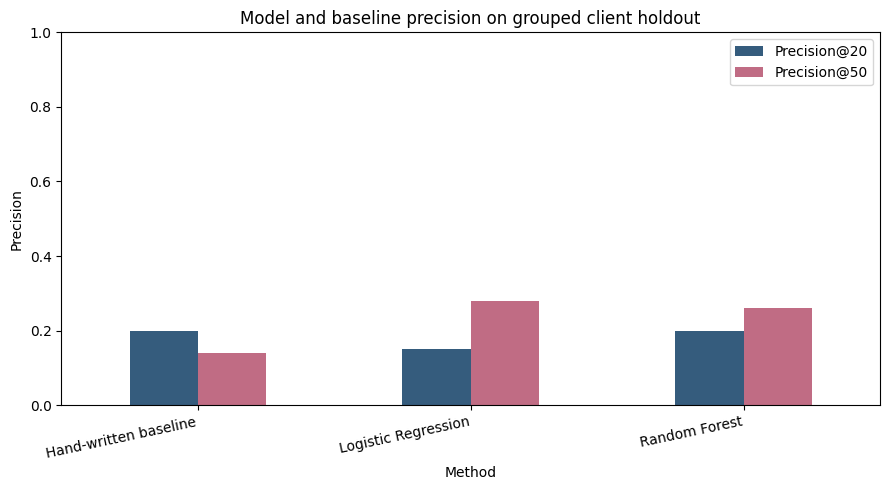

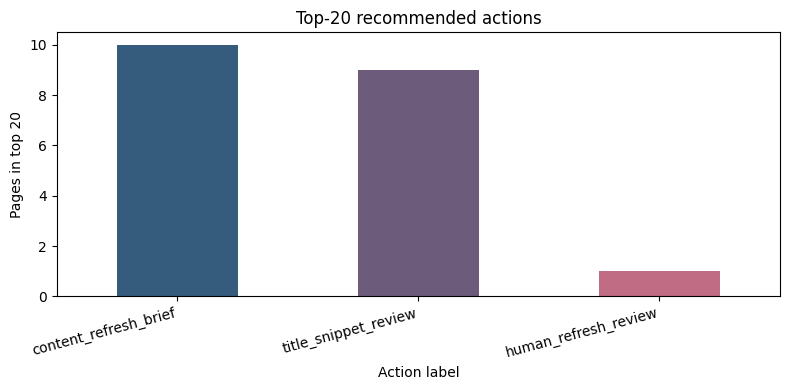

Row-level queue written: work/outputs/capstone_ranked_recommendations.csv
Metrics receipt written: work/outputs/capstone_metrics.json
Comparison figure written: work/figures/capstone_model_comparison.png
Action figure written: work/figures/capstone_top20_actions.png


,data_window,feature_frame_rows,grouped_holdout_train_rows,grouped_holdout_test_rows,grouped_holdout_train_clients,grouped_holdout_test_clients,shared_clients,model_comparison,top20_action_distribution,final_feature_columns,excluded_future_fields,claim_boundary
0,March 2026; features from March 1-15,77540,61747,15793,28,10,0,"[{'method': 'Hand-written baseline', 'Precisio...","{'content_refresh_brief': 10, 'title_snippet_r...","[prior_15d_impressions, prior_15d_clicks, prio...","[next_16d_impressions, is_next_15d_declining]",Decision support for human review; not a guara...


In [24]:
import json

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "capstone_ranked_recommendations.csv"
metrics_path = output_dir / "capstone_metrics.json"
comparison_figure_path = figure_dir / "capstone_model_comparison.png"
actions_figure_path = figure_dir / "capstone_top20_actions.png"

# Row-level queue is regenerated but should not be committed publicly.
action_queue[action_columns].to_csv(queue_path, index=False)

# Figure 1: model comparison on the same grouped client holdout.
chart_data = results_table.set_index("method")[
    ["Precision@20", "Precision@50"]
]

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#355C7D", "#C06C84"]
)

ax.set_title("Model and baseline precision on grouped client holdout")
ax.set_xlabel("Method")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig(comparison_figure_path, dpi=180)
plt.show()

# Figure 2: recommended action distribution.
top20_actions = (
    action_queue.head(20)["action_label"]
    .value_counts()
    .sort_values(ascending=False)
)

ax = top20_actions.plot(
    kind="bar",
    figsize=(8, 4),
    color=["#355C7D", "#6C5B7B", "#C06C84"]
)

ax.set_title("Top-20 recommended actions")
ax.set_xlabel("Action label")
ax.set_ylabel("Pages in top 20")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(actions_figure_path, dpi=180)
plt.show()

capstone_metrics = {
    "data_window": "March 2026; features from March 1-15",
    "feature_frame_rows": int(len(feature_frame)),
    "grouped_holdout_train_rows": int(len(train_df)),
    "grouped_holdout_test_rows": int(len(test_df)),
    "grouped_holdout_train_clients": int(
        train_df["client_hash_id"].nunique()
    ),
    "grouped_holdout_test_clients": int(
        test_df["client_hash_id"].nunique()
    ),
    "shared_clients": int(len(shared_clients)),
    "model_comparison": results_table.round(4).to_dict(
        orient="records"
    ),
    "top20_action_distribution": {
        str(action): int(count)
        for action, count in top20_actions.items()
    },
    "final_feature_columns": feature_columns,
    "excluded_future_fields": [
        "next_16d_impressions",
        "is_next_15d_declining"
    ],
    "claim_boundary": (
        "Decision support for human review; not a guarantee of "
        "decline or content-refresh recovery."
    )
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(capstone_metrics, file, indent=2)

print(f"Row-level queue written: {queue_path}")
print(f"Metrics receipt written: {metrics_path}")
print(f"Comparison figure written: {comparison_figure_path}")
print(f"Action figure written: {actions_figure_path}")

display(pd.DataFrame([capstone_metrics]))

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
